# 2×2 Puzzle Solver - Demonstration

This notebook demonstrates the 2×2 solver with:
- Clean case (high contrast)
- Challenging case (similar textures)
- Intermediate results (edge features, cost matrix)
- Final matching outputs

In [15]:
import cv2
import numpy as np
import os
from itertools import permutations
import matplotlib.pyplot as plt

BORDER_WIDTH = 3
plt.style.use('dark_background')
%matplotlib inline

In [16]:
# Solver functions from 2x2_solver.ipynb
def load_pieces(folder):
    def key(name): return int(''.join(c for c in name if c.isdigit()) or 0)
    files = sorted([f for f in os.listdir(folder) if f.endswith(('.png','.jpg'))], key=key)
    return [cv2.imread(os.path.join(folder, f)) for f in files]

def border(img, side):
    w = BORDER_WIDTH
    if side == 'top': return img[:w]
    if side == 'bottom': return img[-w:]
    if side == 'left': return img[:, :w]
    if side == 'right': return img[:, -w:]

def edge_features(edge):
    edge = cv2.GaussianBlur(edge, (3,3), 0)
    lab = cv2.cvtColor(edge, cv2.COLOR_BGR2LAB).astype(np.float32)
    gray = cv2.cvtColor(edge, cv2.COLOR_BGR2GRAY).astype(np.float32)
    mag = np.sqrt(cv2.Sobel(gray,cv2.CV_32F,1,0)**2 + cv2.Sobel(gray,cv2.CV_32F,0,1)**2)[...,None]
    lap = cv2.Laplacian(gray, cv2.CV_32F)[...,None]
    return np.concatenate([lab, mag, lap], axis=2)

def normalize(f):
    f = f.copy()
    for c in range(f.shape[2]):
        m, s = f[...,c].mean(), max(f[...,c].std(), 1e-6)
        f[...,c] = (f[...,c]-m)/s
    return f

def edge_distance(a, b, sa, sb):
    a, b = normalize(a), normalize(b)
    if sa in ('left','right'): a = np.transpose(a, (1,0,2))
    if sb in ('left','right'): b = np.transpose(b, (1,0,2))
    d = np.abs(a - b)
    return 0.5*d[...,0:3].mean() + 0.3*d[...,3].mean() + 0.2*d[...,4].mean()

def build_costs(pieces):
    opp = {'top':'bottom','bottom':'top','left':'right','right':'left'}
    feats = {(i,s): edge_features(border(p,s)) for i,p in enumerate(pieces) for s in opp}
    cost = {s: np.full((4,4), np.inf) for s in opp}
    for i in range(4):
        for j in range(4):
            if i != j:
                for s in opp:
                    cost[s][i,j] = edge_distance(feats[(i,s)], feats[(j,opp[s])], s, opp[s])
    return cost

def solve_2x2(pieces):
    cost = build_costs(pieces)
    best, best_score = None, 1e18
    for perm in permutations(range(4)):
        score = cost['right'][perm[0],perm[1]] + cost['bottom'][perm[0],perm[2]] + cost['right'][perm[2],perm[3]] + cost['bottom'][perm[1],perm[3]]
        if score < best_score: best_score, best = score, perm
    return list(best), cost

def assemble(pieces, order):
    h, w = pieces[0].shape[:2]
    out = np.zeros((2*h,2*w,3), np.uint8)
    out[0:h,0:w], out[0:h,w:], out[h:,0:w], out[h:,w:] = pieces[order[0]], pieces[order[1]], pieces[order[2]], pieces[order[3]]
    return out

def mse(a,b):
    if a.shape != b.shape: b = cv2.resize(b,(a.shape[1],a.shape[0]))
    return np.mean((a.astype(float)-b.astype(float))**2)

---
## Clean Case - Puzzle #1 (High Contrast)

STEP 1: Input Pieces (Shuffled)


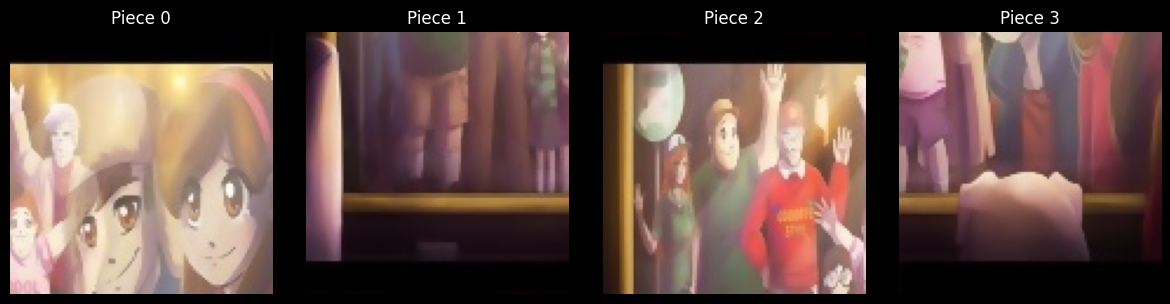


STEP 2: Edge Cost Matrix


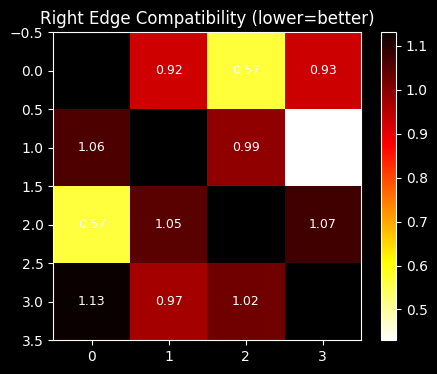


STEP 3: Solution Order = [2, 0, 1, 3]

STEP 4: Final Result


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


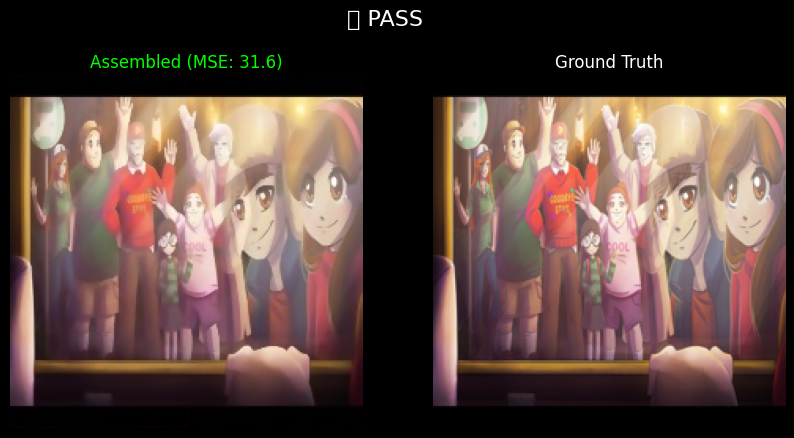

In [17]:
puzzle_id = "1"
pieces = load_pieces(f"./results/enhanced_images_sliced/puzzle_2x2/{puzzle_id}")

print("STEP 1: Input Pieces (Shuffled)")
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(cv2.cvtColor(pieces[i], cv2.COLOR_BGR2RGB))
    ax.set_title(f'Piece {i}'); ax.axis('off')
plt.tight_layout(); plt.show()

print("\n STEP 2: Edge Cost Matrix")
order, cost = solve_2x2(pieces)
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cost['right'], cmap='hot_r')
for i in range(4):
    for j in range(4):
        if cost['right'][i,j] < 1e8:
            ax.text(j, i, f'{cost["right"][i,j]:.2f}', ha='center', va='center', fontsize=9, color='white')
ax.set_title('Right Edge Compatibility (lower=better)'); plt.colorbar(im); plt.show()

print(f"\n STEP 3: Solution Order = {order}")

print("\n STEP 4: Final Result")
assembled = assemble(pieces, order)
gt = cv2.imread(f"../data/correct/{puzzle_id}.png")
if gt is None: gt = cv2.imread(f"../data/correct/{puzzle_id}.jpg")
error = mse(assembled, gt)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(assembled, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Assembled (MSE: {error:.1f})', color='lime' if error<300 else 'red'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(gt, cv2.COLOR_BGR2RGB))
axes[1].set_title('Ground Truth'); axes[1].axis('off')
plt.suptitle(f'✅ PASS' if error<300 else '❌ FAIL', fontsize=16); plt.show()

---
## Challenging Case - Puzzle #31 (Similar Textures)

Input Pieces (Similar colors - challenging!)


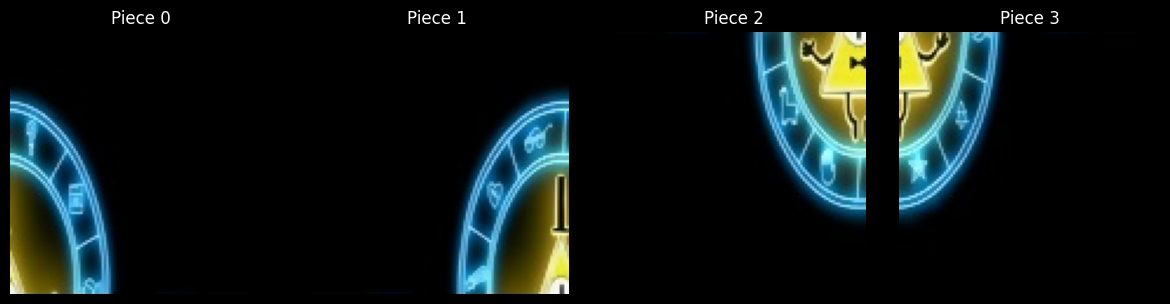


 Final Result


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


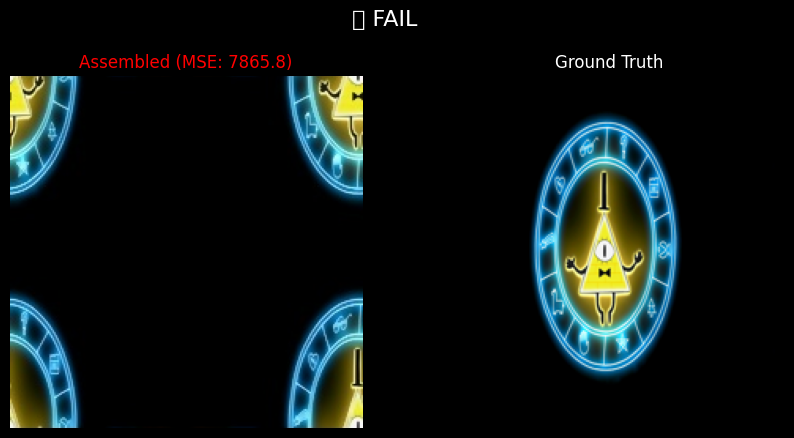


 Analysis: Similar colors cause ambiguous edge matching


In [18]:
puzzle_id = "31"
pieces = load_pieces(f"./results/enhanced_images_sliced/puzzle_2x2/{puzzle_id}")

print(" Input Pieces (Similar colors - challenging!)")
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(cv2.cvtColor(pieces[i], cv2.COLOR_BGR2RGB))
    ax.set_title(f'Piece {i}'); ax.axis('off')
plt.tight_layout(); plt.show()

order, cost = solve_2x2(pieces)
assembled = assemble(pieces, order)
gt = cv2.imread(f"../data/correct/{puzzle_id}.png")
if gt is None: gt = cv2.imread(f"../data/correct/{puzzle_id}.jpg")
error = mse(assembled, gt)

print("\n Final Result")
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(assembled, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Assembled (MSE: {error:.1f})', color='lime' if error<300 else 'red'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(gt, cv2.COLOR_BGR2RGB))
axes[1].set_title('Ground Truth'); axes[1].axis('off')
plt.suptitle(f'✅ PASS' if error<300 else '❌ FAIL', fontsize=16); plt.show()

print("\n Analysis: Similar colors cause ambiguous edge matching")